# 04_5. GARCH 모델 성능 평가

## 목적
GARCH(1,1)의 변동성 예측 성능을 **Baseline(현재 vol_21d)과 공정하게 비교**하여
모델이 파이프라인에 실제로 기여하는지 측정한다.

## 평가 항목

| # | 분석 | 측정 목표 |
|---|------|-----------|
| 1 | **Rank IC 비교** | GARCH vs Baseline — 절대 예측 정확도 차이 |
| 2 | **P 행렬 일치율** | 매월 저위험/고위험 분류가 얼마나 같은지 |
| 3 | **P 분류 정확도** | 실제 다음 달 vol 기준 저위험 종목을 얼마나 맞히는지 |
| 3_5 | **변동성 분리도** | 예측 저위험 그룹의 실제 vol이 고위험보다 낮은가 |
| 3_6 | **P 팩터 수익률** | long 저위험 - short 고위험 스프레드 (분류 경제적 유효성) |
| 4 | **레짐별 분석** | 고변동성 구간에서 GARCH 우위 여부 |

## 설계 원칙
- GARCH 예측: 시점 t 데이터로 t+1 vol 예측 (walk-forward, 04 출력)
- Baseline 예측: 시점 t의 `vol_21d` → t+1 vol 예측 (단순 이월)
- 평가 기준: 시점 t+1의 실제 `vol_21d`
- 동일 유니버스, 동일 기간(2011~2025)으로 공정 비교

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
from scipy.stats import spearmanr
import warnings
import platform
from pathlib import Path

warnings.filterwarnings('ignore')
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / 'data'
OUT_DIR  = BASE_DIR / 'outputs' / '04_5_GARCH_Evaluation'
OUT_DIR.mkdir(parents=True, exist_ok=True)

PCT_GROUP  = 0.30
START_PRED = '2011-01-01'

# ── 데이터 로드 ──────────────────────────────────────────────
panel = pd.read_csv(DATA_DIR / 'monthly_panel.csv', parse_dates=['date'])
panel = panel.set_index(['date', 'ticker'])

all_dates  = panel.index.get_level_values('date').unique().sort_values()
pred_dates = all_dates[all_dates >= START_PRED]

vol_pivot  = panel['vol_21d'].unstack('ticker')   # 실제 vol
spy_series = panel['spy_ret'].groupby(level='date').first()

# GARCH 예측 로드
assert (DATA_DIR / 'vol_predicted.csv').exists(), '04_VolatilityPrediction 먼저 실행하세요'
vol_pred_pivot = (pd.read_csv(DATA_DIR / 'vol_predicted.csv', parse_dates=['date'])
                    .set_index(['date', 'ticker'])['vol_pred']
                    .unstack('ticker'))

print(f'패널: {panel.shape}')
print(f'평가 기간: {pred_dates[0].date()} ~ {pred_dates[-1].date()} ({len(pred_dates)}개월)')
print(f'GARCH 예측: {vol_pred_pivot.shape}')

패널: (108135, 11)
평가 기간: 2011-01-31 ~ 2025-12-31 (180개월)
GARCH 예측: (180, 610)


# 1. Rank IC 비교: GARCH vs Baseline

- **GARCH IC**: `vol_pred[t]` vs 실제 `vol_21d[t]`
- **Baseline IC**: `vol_21d[t-1]` vs 실제 `vol_21d[t]`
- 동일 유니버스(교집합)에서 계산

In [18]:
ic_records = []

for pred_date in pred_dates:
    idx = all_dates.get_loc(pred_date)
    if idx == 0:
        continue
    prev_date = all_dates[idx - 1]

    if pred_date not in vol_pivot.index or pred_date not in vol_pred_pivot.index:
        continue
    if prev_date not in vol_pivot.index:
        continue

    actual   = vol_pivot.loc[pred_date].dropna()
    garch    = vol_pred_pivot.loc[pred_date].dropna()
    baseline = vol_pivot.loc[prev_date].dropna()

    # 세 시리즈 모두 존재하는 종목만
    common = actual.index.intersection(garch.index).intersection(baseline.index)
    if len(common) < 30:
        continue

    ic_g, _ = spearmanr(garch[common],    actual[common])
    ic_b, _ = spearmanr(baseline[common], actual[common])

    ic_records.append({
        'date':     pred_date,
        'IC_GARCH': ic_g,
        'IC_Base':  ic_b,
        'n_tickers': len(common),
    })

ic_df = pd.DataFrame(ic_records).set_index('date')

print('=' * 55)
print('Rank IC 비교 (GARCH vs Baseline)')
print('=' * 55)
print(f'{'':20}  GARCH     Baseline  차이(G-B)')
print(f'{'평균 IC':20}  {ic_df["IC_GARCH"].mean():.4f}    {ic_df["IC_Base"].mean():.4f}    {ic_df["IC_GARCH"].mean()-ic_df["IC_Base"].mean():+.4f}')
print(f'{'중앙값 IC':20}  {ic_df["IC_GARCH"].median():.4f}    {ic_df["IC_Base"].median():.4f}    {ic_df["IC_GARCH"].median()-ic_df["IC_Base"].median():+.4f}')
print(f'{'ICIR':20}  {ic_df["IC_GARCH"].mean()/ic_df["IC_GARCH"].std():.4f}    {ic_df["IC_Base"].mean()/ic_df["IC_Base"].std():.4f}')
print(f'{'양수 비율':20}  {(ic_df["IC_GARCH"]>0).mean():.1%}     {(ic_df["IC_Base"]>0).mean():.1%}')
print(f'{'GARCH 우위 월':20}  {(ic_df["IC_GARCH"]>ic_df["IC_Base"]).sum()}개 / {len(ic_df)}개월')
print(f'{'GARCH 우위 비율':20}  {(ic_df["IC_GARCH"]>ic_df["IC_Base"]).mean():.1%}')

Rank IC 비교 (GARCH vs Baseline)
                      GARCH     Baseline  차이(G-B)
평균 IC                 0.5875    0.5680    +0.0194
중앙값 IC                0.5855    0.5677    +0.0178
ICIR                  7.2803    5.1041
양수 비율                 100.0%     100.0%
GARCH 우위 월            104개 / 180개월
GARCH 우위 비율           57.8%


# 2. P 행렬 일치율

매월 GARCH와 Baseline이 저위험/고위험 그룹을 얼마나 동일하게 분류하는지 측정.
일치율이 높을수록 GARCH의 차별적 기여가 작다는 의미.

In [19]:
def get_groups(vol_series, pct=PCT_GROUP):
    n = max(1, int(len(vol_series) * pct))
    s = vol_series.sort_values().index
    return set(s[:n]), set(s[-n:])


overlap_records = []

for pred_date in pred_dates:
    idx = all_dates.get_loc(pred_date)
    if idx == 0 or pred_date not in vol_pred_pivot.index:
        continue
    prev_date = all_dates[idx - 1]
    if prev_date not in vol_pivot.index:
        continue

    garch_vol = vol_pred_pivot.loc[pred_date].dropna()
    base_vol  = vol_pivot.loc[prev_date].dropna()
    common    = garch_vol.index.intersection(base_vol.index)
    if len(common) < 30:
        continue

    g_low, g_high = get_groups(garch_vol[common])
    b_low, b_high = get_groups(base_vol[common])

    n_group = len(g_low)
    low_overlap  = len(g_low  & b_low)  / n_group
    high_overlap = len(g_high & b_high) / n_group

    overlap_records.append({
        'date':         pred_date,
        'low_overlap':  low_overlap,
        'high_overlap': high_overlap,
        'avg_overlap':  (low_overlap + high_overlap) / 2,
        'n_group':      n_group,
    })

ov_df = pd.DataFrame(overlap_records).set_index('date')

print('=' * 50)
print('P 행렬 일치율 (GARCH vs Baseline)')
print('=' * 50)
print(f'저위험 그룹 평균 일치율:  {ov_df["low_overlap"].mean():.1%}')
print(f'고위험 그룹 평균 일치율:  {ov_df["high_overlap"].mean():.1%}')
print(f'전체 평균 일치율:         {ov_df["avg_overlap"].mean():.1%}')
print(f'일치율 90% 이상인 월:     {(ov_df["avg_overlap"]>=0.9).sum()}개 / {len(ov_df)}개월')
print(f'일치율 50% 미만인 월:     {(ov_df["avg_overlap"]<0.5).sum()}개월  ← GARCH가 실질적으로 다른 분류를 한 구간')

P 행렬 일치율 (GARCH vs Baseline)
저위험 그룹 평균 일치율:  58.9%
고위험 그룹 평균 일치율:  62.3%
전체 평균 일치율:         60.6%
일치율 90% 이상인 월:     0개 / 180개월
일치율 50% 미만인 월:     2개월  ← GARCH가 실질적으로 다른 분류를 한 구간


# 3. P 분류 정확도 (Precision)

실제 다음 달 vol 기준 저위험 30% 종목이 정답.
GARCH와 Baseline이 이 정답을 얼마나 맞히는지 Precision으로 측정.

$$\text{Precision}_{\text{low}} = \frac{|\hat{\text{low}} \cap \text{actual low}|}{|\hat{\text{low}}|}$$

In [20]:
precision_records = []

for pred_date in pred_dates:
    idx = all_dates.get_loc(pred_date)
    if idx == 0 or pred_date not in vol_pred_pivot.index:
        continue
    prev_date = all_dates[idx - 1]
    next_idx  = idx + 1
    if next_idx >= len(all_dates):
        continue
    next_date = all_dates[next_idx]   # 다음 달 실제 vol

    if prev_date not in vol_pivot.index or next_date not in vol_pivot.index:
        continue

    garch_vol  = vol_pred_pivot.loc[pred_date].dropna()
    base_vol   = vol_pivot.loc[prev_date].dropna()
    actual_vol = vol_pivot.loc[next_date].dropna()

    common = garch_vol.index.intersection(base_vol.index).intersection(actual_vol.index)
    if len(common) < 30:
        continue

    g_low, g_high   = get_groups(garch_vol[common])
    b_low, b_high   = get_groups(base_vol[common])
    a_low, a_high   = get_groups(actual_vol[common])  # 정답

    precision_records.append({
        'date':            pred_date,
        'garch_prec_low':  len(g_low  & a_low)  / len(g_low),
        'garch_prec_high': len(g_high & a_high) / len(g_high),
        'base_prec_low':   len(b_low  & a_low)  / len(b_low),
        'base_prec_high':  len(b_high & a_high) / len(b_high),
    })

pr_df = pd.DataFrame(precision_records).set_index('date')
pr_df['garch_prec_avg'] = (pr_df['garch_prec_low'] + pr_df['garch_prec_high']) / 2
pr_df['base_prec_avg']  = (pr_df['base_prec_low']  + pr_df['base_prec_high'])  / 2

print('=' * 60)
print('P 분류 정확도 (실제 다음 달 vol 기준)')
print('=' * 60)
print(f'                    GARCH     Baseline  차이(G-B)')
print(f'저위험 Precision:   {pr_df["garch_prec_low"].mean():.3f}     {pr_df["base_prec_low"].mean():.3f}     {pr_df["garch_prec_low"].mean()-pr_df["base_prec_low"].mean():+.3f}')
print(f'고위험 Precision:   {pr_df["garch_prec_high"].mean():.3f}     {pr_df["base_prec_high"].mean():.3f}     {pr_df["garch_prec_high"].mean()-pr_df["base_prec_high"].mean():+.3f}')
print(f'평균 Precision:     {pr_df["garch_prec_avg"].mean():.3f}     {pr_df["base_prec_avg"].mean():.3f}     {pr_df["garch_prec_avg"].mean()-pr_df["base_prec_avg"].mean():+.3f}')
print(f'\n[참고] 랜덤 분류 기대값: {PCT_GROUP:.0%} (PCT_GROUP = {PCT_GROUP})')

P 분류 정확도 (실제 다음 달 vol 기준)
                    GARCH     Baseline  차이(G-B)
저위험 Precision:   0.571     0.546     +0.025
고위험 Precision:   0.598     0.580     +0.018
평균 Precision:     0.584     0.563     +0.021

[참고] 랜덤 분류 기대값: 30% (PCT_GROUP = 0.3)


# 3_5. 변동성 분리도 & 팩터 수익률

예측 그룹 크기 = 실제 그룹 크기 = n_group이므로 Precision = Recall = F1 (수학적으로 동일).  
그보다 실질적으로 중요한 두 지표를 측정한다.

- **변동성 분리도**: 예측 저위험 그룹의 실제 다음달 vol이 고위험 그룹보다 낮은가  
- **P 팩터 수익률**: long 저위험 - short 고위험의 실제 수익 스프레드 → 양수이면 분류가 경제적으로 유효

In [21]:
vol_sep_records  = []
factor_records   = []

for pred_date in pred_dates:
    idx = all_dates.get_loc(pred_date)
    if idx == 0 or pred_date not in vol_pred_pivot.index:
        continue
    prev_date = all_dates[idx - 1]
    next_idx  = idx + 1
    if next_idx >= len(all_dates):
        continue
    next_date = all_dates[next_idx]   # 다음달 실제 vol 평가 기준

    if prev_date not in vol_pivot.index or next_date not in vol_pivot.index:
        continue

    garch_vol  = vol_pred_pivot.loc[pred_date].dropna()
    base_vol   = vol_pivot.loc[prev_date].dropna()
    actual_vol = vol_pivot.loc[next_date].dropna()   # 다음달 실제 변동성

    try:
        actual_ret = panel.xs(pred_date, level='date')['fwd_ret_1m'].dropna()
    except KeyError:
        continue

    common = (garch_vol.index
               .intersection(base_vol.index)
               .intersection(actual_vol.index)
               .intersection(actual_ret.index))
    if len(common) < 30:
        continue

    g_low, g_high = get_groups(garch_vol[common])
    b_low, b_high = get_groups(base_vol[common])

    # ── 변동성 분리도 ──────────────────────────────────────
    g_vol_low  = actual_vol[list(g_low)].mean()
    g_vol_high = actual_vol[list(g_high)].mean()
    b_vol_low  = actual_vol[list(b_low)].mean()
    b_vol_high = actual_vol[list(b_high)].mean()

    vol_sep_records.append({
        'date':           pred_date,
        'g_vol_low':      g_vol_low,
        'g_vol_high':     g_vol_high,
        'g_vol_ratio':    g_vol_low / g_vol_high,   # <1이면 분리 성공
        'g_sep_ok':       int(g_vol_low < g_vol_high),
        'g_vol_gap':      g_vol_high - g_vol_low,   # 절대 차이
        'b_vol_low':      b_vol_low,
        'b_vol_high':     b_vol_high,
        'b_vol_ratio':    b_vol_low / b_vol_high,
        'b_sep_ok':       int(b_vol_low < b_vol_high),
        'b_vol_gap':      b_vol_high - b_vol_low,
    })

    # ── P 팩터 수익률 (등비중 long-short) ─────────────────
    g_ret_long  = actual_ret[list(g_low)].mean()    # long: 저위험
    g_ret_short = actual_ret[list(g_high)].mean()   # short: 고위험
    b_ret_long  = actual_ret[list(b_low)].mean()
    b_ret_short = actual_ret[list(b_high)].mean()

    factor_records.append({
        'date':          pred_date,
        'g_long_ret':    g_ret_long,
        'g_short_ret':   g_ret_short,
        'g_factor':      g_ret_long - g_ret_short,
        'b_long_ret':    b_ret_long,
        'b_short_ret':   b_ret_short,
        'b_factor':      b_ret_long - b_ret_short,
    })

vs_df  = pd.DataFrame(vol_sep_records).set_index('date')
fac_df = pd.DataFrame(factor_records).set_index('date')

ANN = np.sqrt(12)

print('=' * 65)
print('변동성 분리도 — 예측 그룹별 실제 다음달 vol')
print('=' * 65)
print(f'                         GARCH       Baseline')
print(f'예측 저위험 그룹 평균 vol:  {vs_df["g_vol_low"].mean():.4f}      {vs_df["b_vol_low"].mean():.4f}')
print(f'예측 고위험 그룹 평균 vol:  {vs_df["g_vol_high"].mean():.4f}      {vs_df["b_vol_high"].mean():.4f}')
print(f'vol 비율 (low/high):        {vs_df["g_vol_ratio"].mean():.4f}      {vs_df["b_vol_ratio"].mean():.4f}   ← 낮을수록 분리 우수')
print(f'vol 절대 갭 (high-low):     {vs_df["g_vol_gap"].mean():.4f}      {vs_df["b_vol_gap"].mean():.4f}')
print(f'분리 성공률 (저<고 인 달):  {vs_df["g_sep_ok"].mean():.1%}       {vs_df["b_sep_ok"].mean():.1%}')
print()
print('=' * 65)
print('P 팩터 수익률 — long 저위험 / short 고위험 (등비중)')
print('=' * 65)
print(f'                      GARCH        Baseline')
print(f'long(저위험) 평균 수익: {fac_df["g_long_ret"].mean()*100:+.3f}%/월    {fac_df["b_long_ret"].mean()*100:+.3f}%/월')
print(f'short(고위험) 평균 수익:{fac_df["g_short_ret"].mean()*100:+.3f}%/월    {fac_df["b_short_ret"].mean()*100:+.3f}%/월')
print(f'팩터 스프레드:          {fac_df["g_factor"].mean()*100:+.3f}%/월    {fac_df["b_factor"].mean()*100:+.3f}%/월')
print(f'연환산 팩터 수익:       {fac_df["g_factor"].mean()*12*100:+.2f}%/년    {fac_df["b_factor"].mean()*12*100:+.2f}%/년')
print(f'팩터 Sharpe:            {fac_df["g_factor"].mean()/fac_df["g_factor"].std()*ANN:+.3f}        {fac_df["b_factor"].mean()/fac_df["b_factor"].std()*ANN:+.3f}')
print(f'양수 비율:              {(fac_df["g_factor"]>0).mean():.1%}         {(fac_df["b_factor"]>0).mean():.1%}')
print()
print('[해석]')
print(f'  팩터 스프레드가 양수({fac_df["g_factor"].mean()*100:+.2f}%/월)이면 저위험 분류가 실제로 유효')
print(f'  vol 비율 < 1이면 예측 저위험 종목의 실제 vol이 더 낮음 (분류 정확)')

# 저장
vs_df.to_csv(OUT_DIR / 'vol_separation.csv')
fac_df.to_csv(OUT_DIR / 'factor_returns.csv')

변동성 분리도 — 예측 그룹별 실제 다음달 vol
                         GARCH       Baseline
예측 저위험 그룹 평균 vol:  0.2058      0.2100
예측 고위험 그룹 평균 vol:  0.3549      0.3510
vol 비율 (low/high):        0.5759      0.5997   ← 낮을수록 분리 우수
vol 절대 갭 (high-low):     0.1490      0.1410
분리 성공률 (저<고 인 달):  100.0%       100.0%

P 팩터 수익률 — long 저위험 / short 고위험 (등비중)
                      GARCH        Baseline
long(저위험) 평균 수익: +1.050%/월    +1.051%/월
short(고위험) 평균 수익:+1.291%/월    +1.305%/월
팩터 스프레드:          -0.241%/월    -0.254%/월
연환산 팩터 수익:       -2.89%/년    -3.05%/년
팩터 Sharpe:            -0.197        -0.213
양수 비율:              51.4%         48.6%

[해석]
  팩터 스프레드가 양수(-0.24%/월)이면 저위험 분류가 실제로 유효
  vol 비율 < 1이면 예측 저위험 종목의 실제 vol이 더 낮음 (분류 정확)


# 3_6. 분리도 & 팩터 수익률 시각화

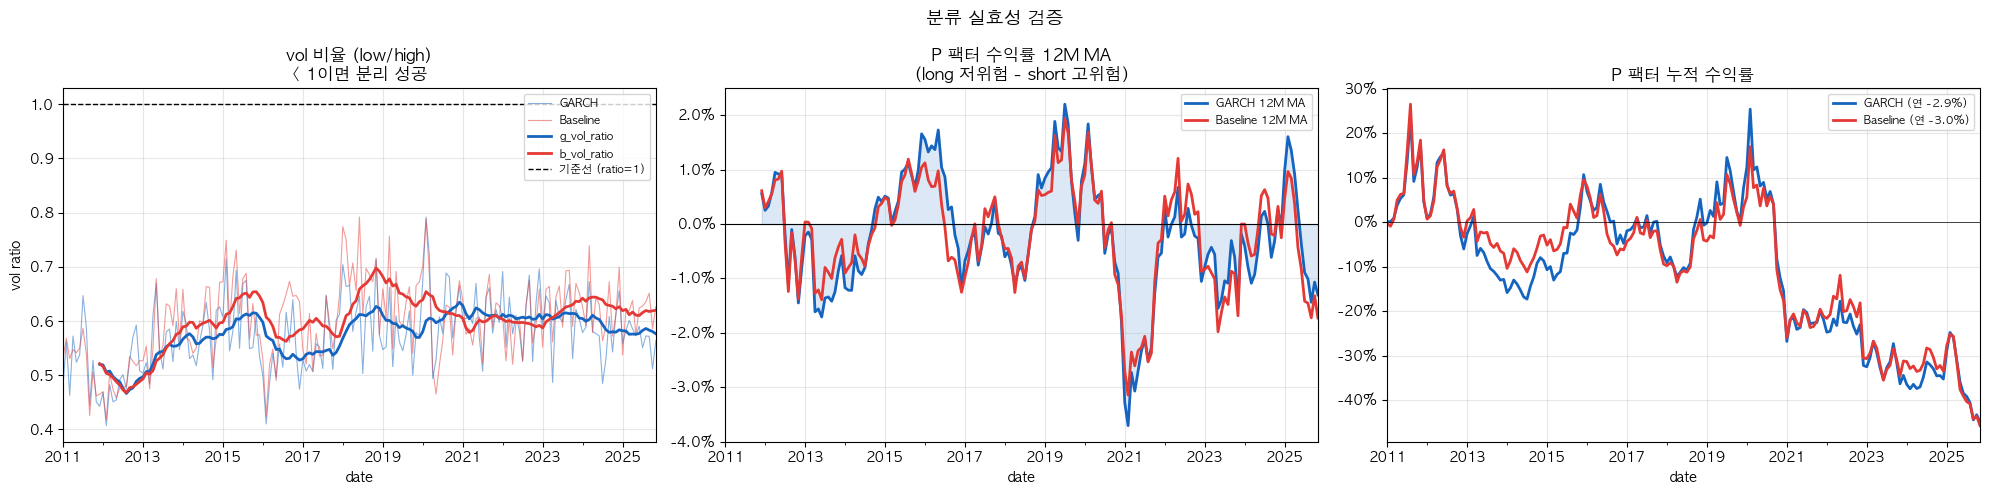

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('분류 실효성 검증', fontsize=13, fontweight='bold')

# ① vol 비율 시계열
ax = axes[0]
vs_df['g_vol_ratio'].plot(ax=ax, color='#1565C0', alpha=0.5, linewidth=0.8, label='GARCH')
vs_df['b_vol_ratio'].plot(ax=ax, color='#E53935', alpha=0.5, linewidth=0.8, label='Baseline')
vs_df['g_vol_ratio'].rolling(12).mean().plot(ax=ax, color='#1565C0', linewidth=2.0)
vs_df['b_vol_ratio'].rolling(12).mean().plot(ax=ax, color='#E53935', linewidth=2.0)
ax.axhline(1.0, color='black', linewidth=1.0, linestyle='--', label='기준선 (ratio=1)')
ax.set_title('vol 비율 (low/high)\n< 1이면 분리 성공')
ax.set_ylabel('vol ratio')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ② 팩터 수익률 시계열
ax = axes[1]
fac_df['g_factor'].rolling(12).mean().plot(ax=ax, color='#1565C0', linewidth=2.0, label='GARCH 12M MA')
fac_df['b_factor'].rolling(12).mean().plot(ax=ax, color='#E53935', linewidth=2.0, label='Baseline 12M MA')
ax.axhline(0, color='black', linewidth=0.8)
ax.fill_between(fac_df.index,
                fac_df['g_factor'].rolling(12).mean(),
                0, alpha=0.15, color='#1565C0')
ax.set_title('P 팩터 수익률 12M MA\n(long 저위험 - short 고위험)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ③ 팩터 수익률 누적
ax = axes[2]
((1 + fac_df['g_factor']).cumprod() - 1).plot(
    ax=ax, color='#1565C0', linewidth=2.0, label=f'GARCH (연 {fac_df["g_factor"].mean()*12*100:.1f}%)')
((1 + fac_df['b_factor']).cumprod() - 1).plot(
    ax=ax, color='#E53935', linewidth=2.0, label=f'Baseline (연 {fac_df["b_factor"].mean()*12*100:.1f}%)')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_title('P 팩터 누적 수익률')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'classification_validity.png', dpi=150, bbox_inches='tight')
plt.show()

# 4. 레짐별 분석

SPY 12개월 롤링 변동성으로 고변동성/저변동성 구간을 정의하고
각 구간에서 GARCH 우위 여부를 확인한다.

- **고변동성 구간**: 롤링 변동성 상위 33% 구간 (예: 2018년 말, 2020 코로나, 2022)
- **저변동성 구간**: 하위 33%

In [23]:
# SPY 롤링 12개월 변동성으로 레짐 정의
spy_roll_vol = spy_series.rolling(12).std() * np.sqrt(12)
spy_roll_vol = spy_roll_vol.reindex(ic_df.index)

q33 = spy_roll_vol.quantile(0.33)
q67 = spy_roll_vol.quantile(0.67)

regime = pd.Series('중간', index=ic_df.index)
regime[spy_roll_vol <= q33] = '저변동성'
regime[spy_roll_vol >= q67] = '고변동성'

print('=' * 65)
print('레짐별 IC 비교')
print('=' * 65)
print(f'  레짐 정의: SPY 12개월 롤링 변동성 (q33={q33:.3f}, q67={q67:.3f})')
print()

for reg in ['저변동성', '중간', '고변동성']:
    mask = regime == reg
    sub  = ic_df[mask]
    n    = mask.sum()
    if n == 0:
        continue
    g_mean = sub['IC_GARCH'].mean()
    b_mean = sub['IC_Base'].mean()
    garch_wins = (sub['IC_GARCH'] > sub['IC_Base']).sum()
    print(f'  [{reg}] {n}개월')
    print(f'    GARCH IC:    {g_mean:.4f}')
    print(f'    Baseline IC: {b_mean:.4f}')
    print(f'    차이(G-B):   {g_mean-b_mean:+.4f}  |  GARCH 우위: {garch_wins}/{n} ({garch_wins/n:.1%})')
    print()

# 고변동성 구간 날짜 확인
high_vol_dates = regime[regime == '고변동성'].index
print(f'  고변동성 구간 주요 기간: {high_vol_dates.min().date()} ~ (연도별 분포)')
print('  ' + str(high_vol_dates.year.value_counts().sort_index().to_dict()))

레짐별 IC 비교
  레짐 정의: SPY 12개월 롤링 변동성 (q33=0.107, q67=0.152)

  [저변동성] 60개월
    GARCH IC:    0.5631
    Baseline IC: 0.5122
    차이(G-B):   +0.0509  |  GARCH 우위: 44/60 (73.3%)

  [중간] 60개월
    GARCH IC:    0.5864
    Baseline IC: 0.5727
    차이(G-B):   +0.0136  |  GARCH 우위: 33/60 (55.0%)

  [고변동성] 60개월
    GARCH IC:    0.6130
    Baseline IC: 0.6191
    차이(G-B):   -0.0062  |  GARCH 우위: 27/60 (45.0%)

  고변동성 구간 주요 기간: 2011-01-31 ~ (연도별 분포)
  {2011: 8, 2012: 8, 2019: 11, 2020: 10, 2021: 3, 2022: 9, 2023: 10, 2024: 1}


# 5. 종합 시각화

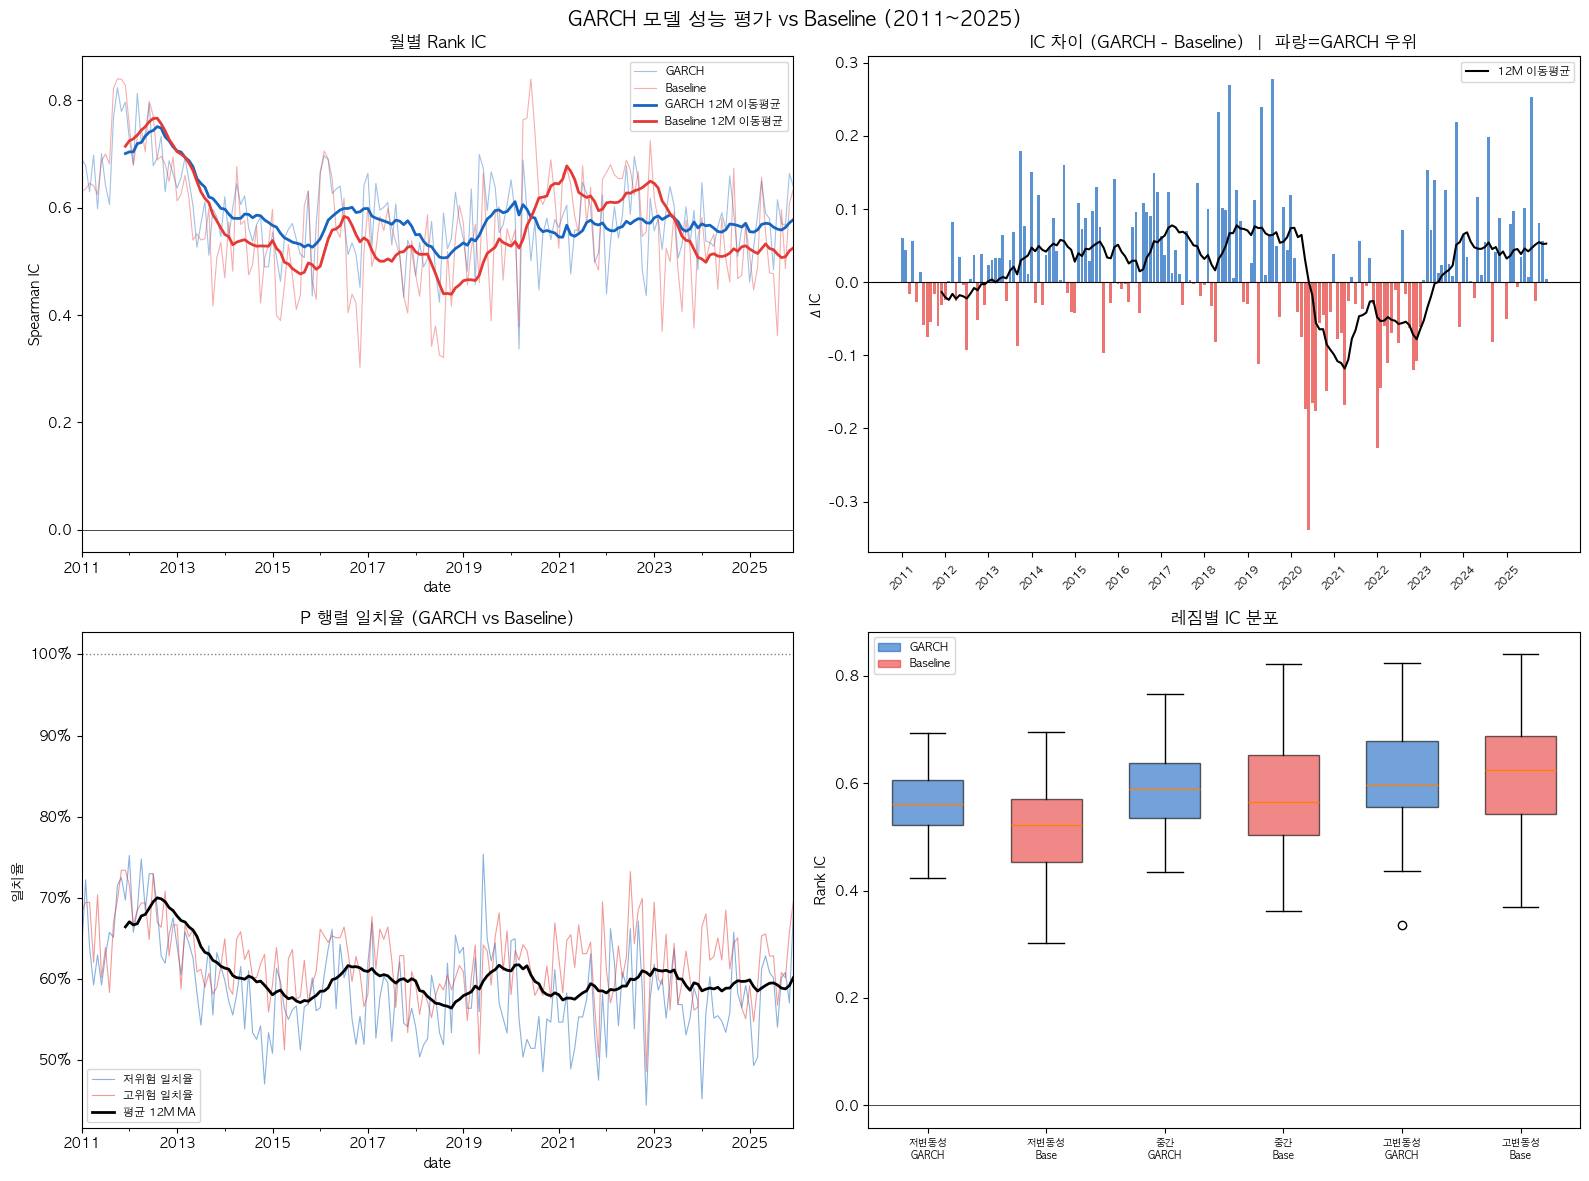

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('GARCH 모델 성능 평가 vs Baseline (2011~2025)', fontsize=14, fontweight='bold')

# ① Rank IC 시계열
ax = axes[0, 0]
ic_df['IC_GARCH'].plot(ax=ax, color='#1565C0', alpha=0.4, linewidth=0.8, label='GARCH')
ic_df['IC_Base'].plot(ax=ax,  color='#E53935', alpha=0.4, linewidth=0.8, label='Baseline')
ic_df['IC_GARCH'].rolling(12).mean().plot(ax=ax, color='#1565C0', linewidth=2.0, label='GARCH 12M 이동평균')
ic_df['IC_Base'].rolling(12).mean().plot(ax=ax,  color='#E53935', linewidth=2.0, label='Baseline 12M 이동평균')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_title('월별 Rank IC')
ax.set_ylabel('Spearman IC')
ax.legend(fontsize=8)

# ② IC 차이 (GARCH - Baseline)
ax = axes[0, 1]
ic_diff = ic_df['IC_GARCH'] - ic_df['IC_Base']
colors  = ['#1565C0' if v >= 0 else '#E53935' for v in ic_diff]
ax.bar(range(len(ic_diff)), ic_diff.values, color=colors, alpha=0.7, width=0.8)
ic_diff.rolling(12).mean().values  # 이동평균
ax.plot(range(len(ic_diff)), ic_diff.rolling(12).mean().values,
        color='black', linewidth=1.5, label='12M 이동평균')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('IC 차이 (GARCH - Baseline)  |  파랑=GARCH 우위')
ax.set_ylabel('ΔIC')
ax.set_xticks(range(0, len(ic_diff), 12))
ax.set_xticklabels([str(d.year) for d in ic_diff.index[::12]], rotation=45, fontsize=8)
ax.legend(fontsize=8)

# ③ P 행렬 일치율
ax = axes[1, 0]
ov_df['low_overlap'].plot(ax=ax,  color='#1565C0', alpha=0.5, linewidth=0.8, label='저위험 일치율')
ov_df['high_overlap'].plot(ax=ax, color='#E53935', alpha=0.5, linewidth=0.8, label='고위험 일치율')
ov_df['avg_overlap'].rolling(12).mean().plot(ax=ax, color='black', linewidth=2.0, label='평균 12M MA')
ax.axhline(1.0, color='gray', linestyle=':', linewidth=1.0)
ax.set_title('P 행렬 일치율 (GARCH vs Baseline)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylabel('일치율')
ax.legend(fontsize=8)

# ④ 레짐별 IC 비교 (박스플롯)
ax = axes[1, 1]
reg_data = []
labels   = []
colors_box = []
for reg in ['저변동성', '중간', '고변동성']:
    mask = regime == reg
    reg_data.append(ic_df.loc[mask, 'IC_GARCH'].values)
    reg_data.append(ic_df.loc[mask, 'IC_Base'].values)
    labels += [f'{reg}\nGARCH', f'{reg}\nBase']
    colors_box += ['#1565C0', '#E53935']

bp = ax.boxplot(reg_data, patch_artist=True, widths=0.6)
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_xticklabels(labels, fontsize=7)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_title('레짐별 IC 분포')
ax.set_ylabel('Rank IC')
blue_patch = mpatches.Patch(color='#1565C0', alpha=0.6, label='GARCH')
red_patch  = mpatches.Patch(color='#E53935', alpha=0.6, label='Baseline')
ax.legend(handles=[blue_patch, red_patch], fontsize=8)

plt.tight_layout()
plt.savefig(OUT_DIR / 'garch_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

# 6. 종합 결론

In [25]:
g_ic   = ic_df['IC_GARCH'].mean()
b_ic   = ic_df['IC_Base'].mean()
ic_gap = g_ic - b_ic
ov_avg = ov_df['avg_overlap'].mean()
pr_gap = pr_df['garch_prec_avg'].mean() - pr_df['base_prec_avg'].mean()

garch_wins_pct = (ic_df['IC_GARCH'] > ic_df['IC_Base']).mean()

# 고변동성 구간 GARCH 우위
high_mask     = regime == '고변동성'
high_ic_gap   = (ic_df.loc[high_mask, 'IC_GARCH'] - ic_df.loc[high_mask, 'IC_Base']).mean()

print('=' * 60)
print('GARCH 모델 평가 종합')
print('=' * 60)
print()
print(f'① Rank IC 절대값: GARCH {g_ic:.4f}  Baseline {b_ic:.4f}  차이 {ic_gap:+.4f}')
print(f'   GARCH 우위 비율: {garch_wins_pct:.1%}')
print()
print(f'② P 행렬 평균 일치율: {ov_avg:.1%}')
print(f'   → 매월 {ov_avg:.0%}의 종목은 GARCH와 Baseline이 동일하게 분류')
print()
print(f'③ 분류 Precision 차이: {pr_gap:+.4f}')
print(f'   → GARCH가 실제 저위험 종목을 더 잘 맞히는가')
print()
print(f'④ 고변동성 구간 IC 차이: {high_ic_gap:+.4f}')
print(f'   → 시장 스트레스 구간에서 GARCH 추가 기여도')
print()

# 결론 판정
print('─' * 60)
print('결론')
print('─' * 60)
if abs(ic_gap) < 0.01:
    print('  IC 차이 < 0.01: GARCH와 Baseline의 예측 정확도가 거의 동일')
elif ic_gap > 0:
    print(f'  IC 차이 +{ic_gap:.4f}: GARCH가 Baseline보다 예측 정확도 우위')
else:
    print(f'  IC 차이 {ic_gap:.4f}: Baseline이 GARCH보다 예측 정확도 우위')

if ov_avg > 0.85:
    print(f'  P 일치율 {ov_avg:.0%}: 두 방법의 분류 결과가 거의 동일 → 포트폴리오 차이 작을 수밖에 없음')
elif ov_avg > 0.70:
    print(f'  P 일치율 {ov_avg:.0%}: 일부 달은 GARCH가 실질적으로 다른 종목을 선택')
else:
    print(f'  P 일치율 {ov_avg:.0%}: GARCH가 Baseline과 상당히 다른 분류 → 의미 있는 차별화')

if high_ic_gap > 0.01:
    print(f'  고변동성 구간 우위 {high_ic_gap:+.4f}: GARCH는 시장 스트레스 구간에서 특히 유용')


# 변동성 분리도 & 팩터 수익률 추가 출력
if 'vs_df' in dir() and len(vs_df) > 0:
    print()
    print(f'⑤ 변동성 분리도: GARCH vol 비율 {vs_df["g_vol_ratio"].mean():.4f}  Baseline {vs_df["b_vol_ratio"].mean():.4f}')
    print(f'   분리 성공률: GARCH {vs_df["g_sep_ok"].mean():.1%}  Baseline {vs_df["b_sep_ok"].mean():.1%}')
if 'fac_df' in dir() and len(fac_df) > 0:
    print(f'⑥ P 팩터 수익률: GARCH {fac_df["g_factor"].mean()*100:+.3f}%/월  Baseline {fac_df["b_factor"].mean()*100:+.3f}%/월')
    print(f'   팩터 Sharpe: GARCH {fac_df["g_factor"].mean()/fac_df["g_factor"].std()*ANN:+.3f}  Baseline {fac_df["b_factor"].mean()/fac_df["b_factor"].std()*ANN:+.3f}')
    if fac_df['g_factor'].mean() > 0:
        print('   → 팩터 스프레드 양수: 저위험 분류가 경제적으로 유효함')
    else:
        print('   → 팩터 스프레드 음수: 분류가 수익으로 이어지지 않음 (재검토 필요)')

# 저장
ic_df.to_csv(OUT_DIR / 'rank_ic_comparison.csv')
ov_df.to_csv(OUT_DIR / 'p_overlap.csv')
pr_df.to_csv(OUT_DIR / 'p_precision.csv')
print(f'\n저장: {OUT_DIR}/')

GARCH 모델 평가 종합

① Rank IC 절대값: GARCH 0.5875  Baseline 0.5680  차이 +0.0194
   GARCH 우위 비율: 57.8%

② P 행렬 평균 일치율: 60.6%
   → 매월 61%의 종목은 GARCH와 Baseline이 동일하게 분류

③ 분류 Precision 차이: +0.0212
   → GARCH가 실제 저위험 종목을 더 잘 맞히는가

④ 고변동성 구간 IC 차이: -0.0062
   → 시장 스트레스 구간에서 GARCH 추가 기여도

────────────────────────────────────────────────────────────
결론
────────────────────────────────────────────────────────────
  IC 차이 +0.0194: GARCH가 Baseline보다 예측 정확도 우위
  P 일치율 61%: GARCH가 Baseline과 상당히 다른 분류 → 의미 있는 차별화

⑤ 변동성 분리도: GARCH vol 비율 0.5759  Baseline 0.5997
   분리 성공률: GARCH 100.0%  Baseline 100.0%
⑥ P 팩터 수익률: GARCH -0.241%/월  Baseline -0.254%/월
   팩터 Sharpe: GARCH -0.197  Baseline -0.213
   → 팩터 스프레드 음수: 분류가 수익으로 이어지지 않음 (재검토 필요)

저장: /Users/yoonseokim/2025_main_bootcamp/4th_final_project/finance_project/김윤서/low_risk/outputs/04_5_GARCH_Evaluation/
